# Check Yanan Inhouse scWAT Status
## Xiaonan Wang
## 23Aug2026

In [1]:
suppressPackageStartupMessages({
library(Seurat)
library(dplyr)
library(tidyr)
library(ggplot2)
library(tibble)
library(forcats)
library(scales)
library(patchwork)
})

set.seed(1234)

In [2]:
PROJECT_ROOT <- "/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium"
PIPELINE_REPO <- file.path(PROJECT_ROOT, "adipose_analysis", "YNH_Xenium_scWAT")
RUN_LABEL <- "full_notebook_qc_v2"
QC_RUN_ROOT <- file.path(
  PROJECT_ROOT,
  "adipose_analysis",
  "scwat_qc_outputs",
  RUN_LABEL
)
DOWNSTREAM_ROOT <- file.path(
  PROJECT_ROOT,
  "adipose_analysis",
  "scwat_downstream_outputs",
  RUN_LABEL
)
ANCHOR_ROOT <- file.path(
  DOWNSTREAM_ROOT,
  "Ref_Inhouse_scWAT"
)
INHOUSE_REFERENCE_PATH <- file.path(
  "/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Data/Inhouse_Data/Hu_NatureImmu2026_PRJNA1301548_mouse/Data",
  "Fig1b_sc_all.rds"
)

In [3]:
source(file.path(PIPELINE_REPO, "R", "source.R"))

In [4]:
assert_path_within(PROJECT_ROOT, QC_RUN_ROOT)
assert_path_within(PROJECT_ROOT, DOWNSTREAM_ROOT)
dir.create(DOWNSTREAM_ROOT, recursive = TRUE, showWarnings = FALSE)
assert_path_within(PROJECT_ROOT, ANCHOR_ROOT)
dir.create(ANCHOR_ROOT, recursive = TRUE, showWarnings = FALSE)

In [5]:
theme_cell <- function(base_size = 12) {
  theme_classic(base_size = base_size) +
    theme(
      panel.border = element_rect(
        colour = "black",
        fill = NA,
        linewidth = 0.8
      ),
      axis.line = element_line(colour = "black", linewidth = 0.6),
      axis.text = element_text(colour = "black"),
      axis.title = element_text(colour = "black"),
      strip.background = element_rect(
        fill = "white",
        colour = "black",
        linewidth = 0.8
      ),
      strip.text = element_text(face = "bold"),
      legend.title = element_text(face = "bold"),
      plot.title = element_text(face = "bold"),
      plot.subtitle = element_text(colour = "black")
    )
}

### Load Seurat Obj

In [6]:
scwat_ref <- readRDS(INHOUSE_REFERENCE_PATH)
DefaultAssay(scwat_ref) <- "RNA"

cat("Reference tissue:\n")
print(table(scwat_ref$Tissue))

Reference tissue:

   BM Blood  eWAT   BAT scWAT    SI Colon  Lung 
 2373   424  1148  8555  8075   641  4868  1852 


In [7]:
print(colnames(scwat_ref@meta.data))

 [1] "orig.ident"      "nCount_RNA"      "nFeature_RNA"    "nCount_AbSeq"   
 [5] "nFeature_AbSeq"  "Batch"           "CellName"        "Tissue"         
 [9] "percent.mt"      "RNA_snn_res.0.6" "seurat_clusters" "Anno"           
[13] "eos_cluster"    


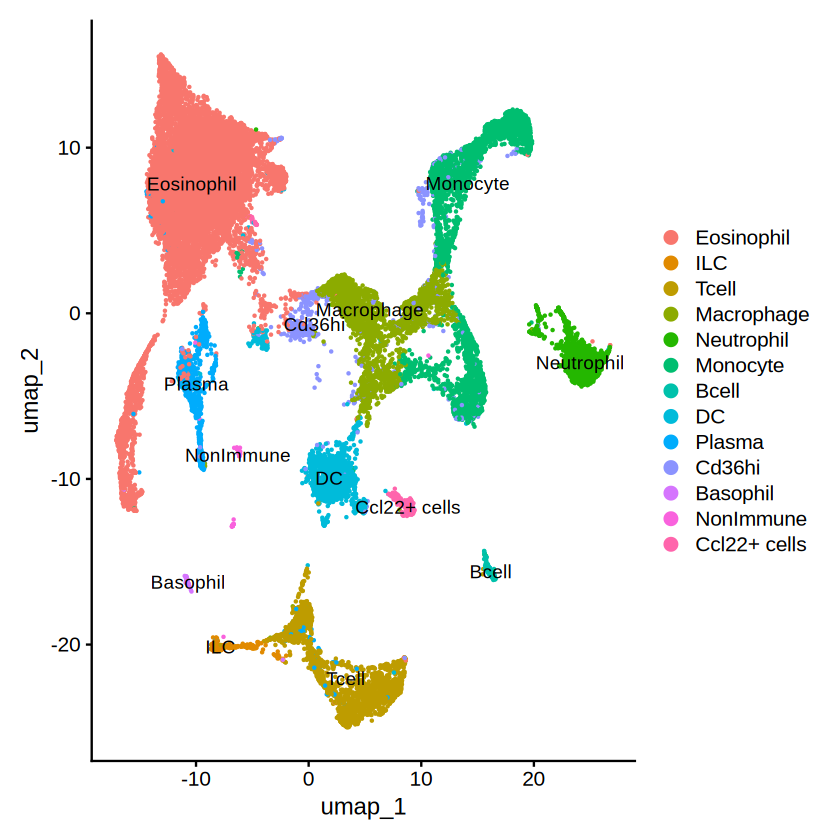

In [8]:
DimPlot(scwat_ref, label = TRUE)

In [54]:
# Key plasma-cell markers
plasma_markers <- c(
  "Jchain",
  "Mzb1",
  "Sdc1",    # CD138
  "Prdm1",   # BLIMP1
  "Xbp1",
  "Derl3"
)

# Keep only genes present in the reference
plasma_markers_use <- intersect(
  plasma_markers,
  rownames(scwat_ref)
)

cat("Markers present:\n")
print(plasma_markers_use)

cat("Markers missing:\n")
print(setdiff(plasma_markers, plasma_markers_use))

Markers present:
[1] "Jchain" "Itgam"  "Sdc1"   "Prdm1"  "Xbp1"   "Derl3" 
Markers missing:
character(0)


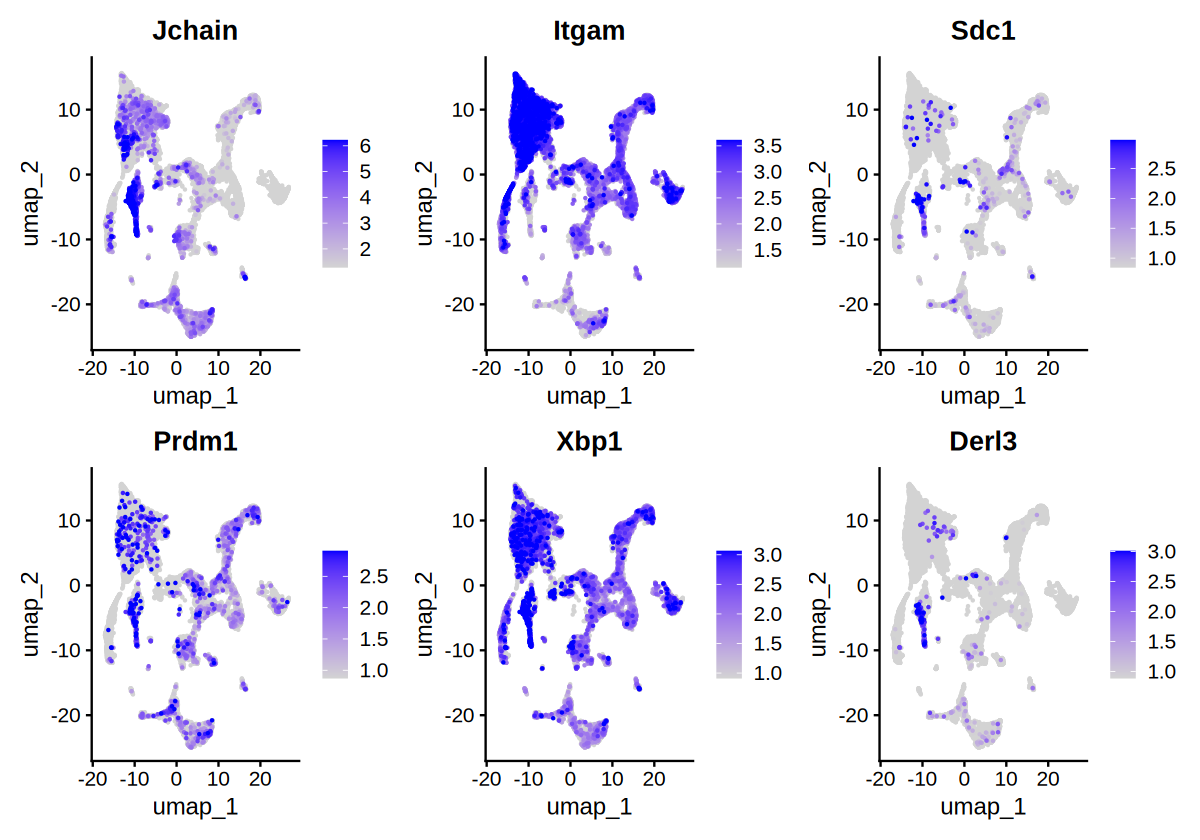

In [55]:
FeaturePlot(
  scwat_ref,
  features = plasma_markers_use,
  reduction = "umap",
  ncol = 3,
  order = TRUE,
  min.cutoff = "q05",
  max.cutoff = "q95"
)

In [9]:
markers = c(
    "Siglecf",
    "Ccr3",
    "Il5ra",
    "Alox15",
    "Ear1",
    "Ear2",
    "Itgam"
)
group_col <- "Anno"
eos_label <- "Eosinophil"

In [10]:
markers_use <- intersect(
  markers,
  rownames(scwat_ref)
)

In [11]:
markers_use

[1] "Siglecf" "Ccr3"    "Il5ra"   "Alox15"  "Ear1"    "Ear2"    "Itgam"

In [12]:
markers_missing <- setdiff(
  markers,
  markers_use
)

In [13]:
markers_missing

character(0)

In [14]:
scwat_ref_use <- subset(
  scwat_ref,
  subset = (Tissue == "scWAT") & (Anno != "NonImmune")
)

Warning message:
“All cells have the same value (4.13141821987058) of “Jchain””
Warning message:
“All cells have the same value (0) of “Mzb1””


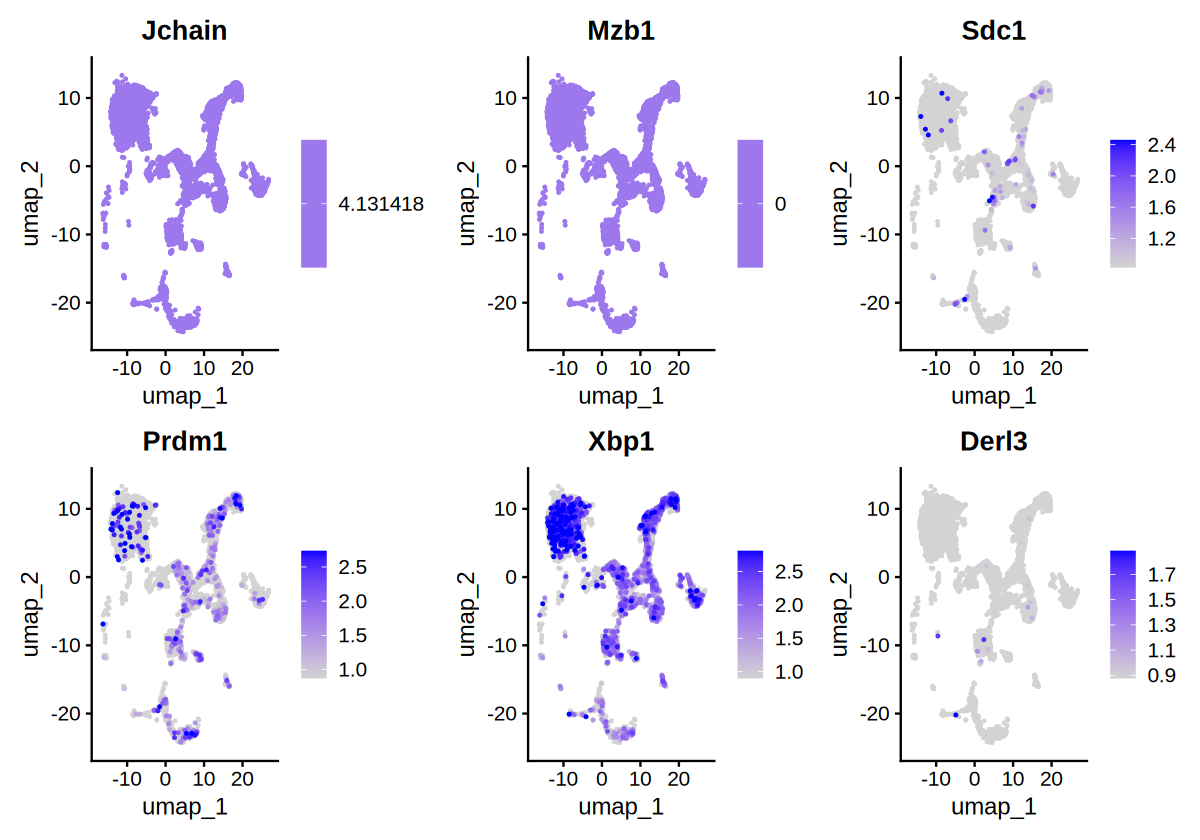

In [52]:
FeaturePlot(
  scwat_ref_use,
  features = plasma_markers_use,
  reduction = "umap",
  ncol = 3,
  order = TRUE,
  min.cutoff = "q05",
  max.cutoff = "q95"
)

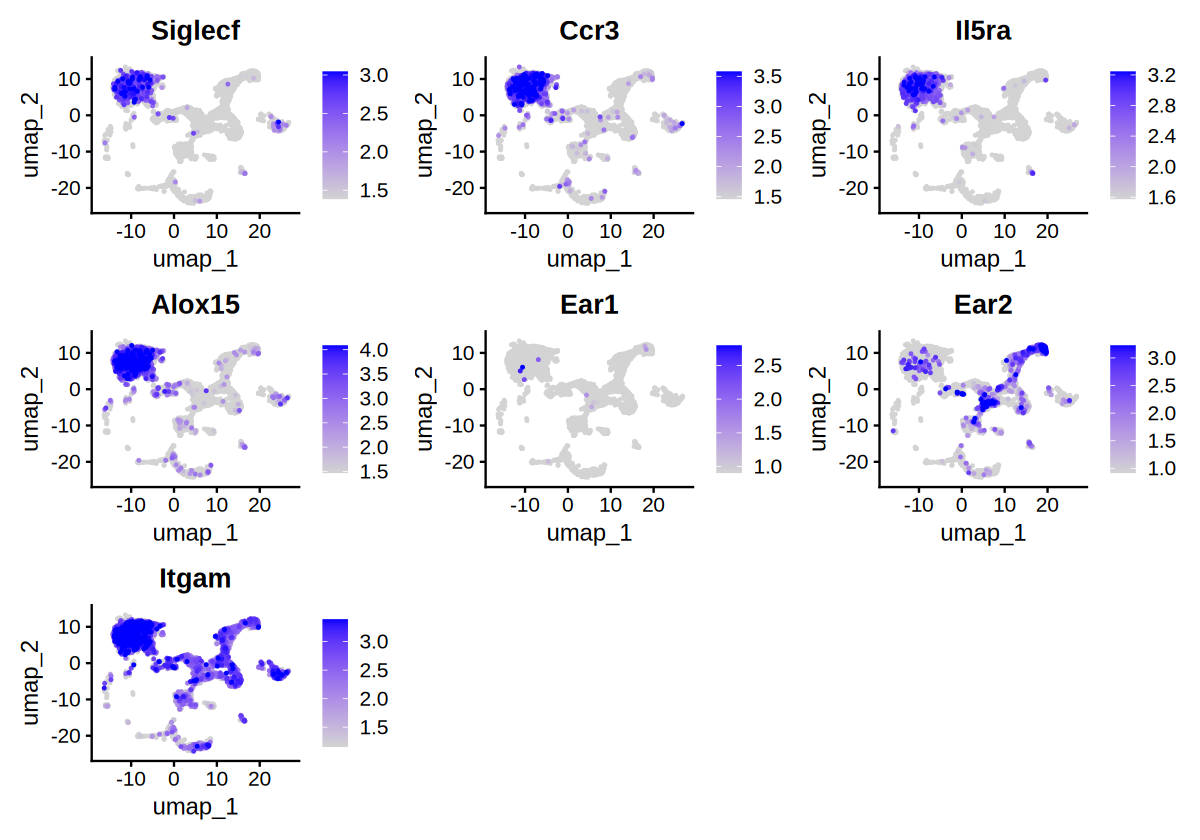

In [53]:
FeaturePlot(
  scwat_ref_use,
  features = markers_use,
  reduction = "umap",
  ncol = 3,
  order = TRUE,
  min.cutoff = "q05",
  max.cutoff = "q95"
)

In [15]:
meta_df <- scwat_ref_use@meta.data %>%
  rownames_to_column("cell")

count_df <- FetchData(
  scwat_ref_use,
  vars = markers_use,
  layer = "counts"
) %>%
  rownames_to_column("cell")

data_df <- FetchData(
  scwat_ref_use,
  vars = markers_use,
  layer = "data"
) %>%
  rownames_to_column("cell")

ref_df <- meta_df %>%
  select(cell, all_of(group_col)) %>%
  rename(CellType = all_of(group_col)) %>%
  left_join(count_df, by = "cell", suffix = c("", "_count")) %>%
  left_join(
    data_df,
    by = "cell",
    suffix = c("_count", "_data")
  )

In [16]:
eos_specific_markers <- intersect(
  c("Siglecf", "Ccr3", "Il5ra", "Alox15", "Ear1", "Ear2"),
  markers_use
)

In [17]:
ref_df <- ref_df %>%
  mutate(
    N_Eos_specific_detected = rowSums(
      across(
        all_of(paste0(eos_specific_markers, "_count")),
        ~ .x > 0
      )
    ),
    N_All_markers_detected = rowSums(
      across(
        all_of(paste0(markers_use, "_count")),
        ~ .x > 0
      )
    )
  )

In [18]:
marker_summary <- purrr::map_dfr(markers_use, function(g) {

  count_col <- paste0(g, "_count")
  data_col  <- paste0(g, "_data")

  ref_df %>%
    group_by(CellType) %>%
    summarise(
      Gene = g,
      n_cells = n(),
      pct_expressing = mean(.data[[count_col]] > 0) * 100,
      mean_expression = mean(.data[[data_col]], na.rm = TRUE),
      median_expression = median(.data[[data_col]], na.rm = TRUE),
      mean_expression_positive = ifelse(
        any(.data[[count_col]] > 0),
        mean(.data[[data_col]][.data[[count_col]] > 0], na.rm = TRUE),
        0
      ),
      .groups = "drop"
    )
})

In [19]:
marker_count_summary <- ref_df %>%
  group_by(CellType) %>%
  summarise(
    n_cells = n(),
    mean_N_Eos_specific = mean(N_Eos_specific_detected),
    median_N_Eos_specific = median(N_Eos_specific_detected),
    pct_ge1 = mean(N_Eos_specific_detected >= 1) * 100,
    pct_ge2 = mean(N_Eos_specific_detected >= 2) * 100,
    pct_ge3 = mean(N_Eos_specific_detected >= 3) * 100,
    pct_ge4 = mean(N_Eos_specific_detected >= 4) * 100,
    pct_ge5 = mean(N_Eos_specific_detected >= 5) * 100,
    .groups = "drop"
  ) %>%
  arrange(desc(mean_N_Eos_specific))

In [20]:
eos_reference <- marker_summary %>%
  filter(CellType == eos_label) %>%
  select(
    Gene,
    Eos_pct_expressing = pct_expressing,
    Eos_mean_expression = mean_expression,
    Eos_mean_expression_positive = mean_expression_positive
  )

marker_vs_eos <- marker_summary %>%
  left_join(eos_reference, by = "Gene") %>%
  mutate(
    delta_pct_vs_Eos = pct_expressing - Eos_pct_expressing,
    Eos_minus_other_mean = Eos_mean_expression - mean_expression,
    log2FC_Eos_vs_other = log2(
      (Eos_mean_expression + 1e-3) / (mean_expression + 1e-3)
    )
  )

In [21]:
eos_marker_count_ref <- marker_count_summary %>%
  filter(CellType == eos_label) %>%
  select(
    Eos_mean_N_Eos_specific = mean_N_Eos_specific,
    Eos_pct_ge2 = pct_ge2,
    Eos_pct_ge3 = pct_ge3
  )

marker_count_vs_eos <- marker_count_summary %>%
  tidyr::crossing(eos_marker_count_ref) %>%
  mutate(
    diff_mean_N_vs_Eos = mean_N_Eos_specific - Eos_mean_N_Eos_specific,
    diff_pct_ge2_vs_Eos = pct_ge2 - Eos_pct_ge2,
    diff_pct_ge3_vs_Eos = pct_ge3 - Eos_pct_ge3
  )

In [62]:
options(repr.plot.width=7, repr.plot.height=7)

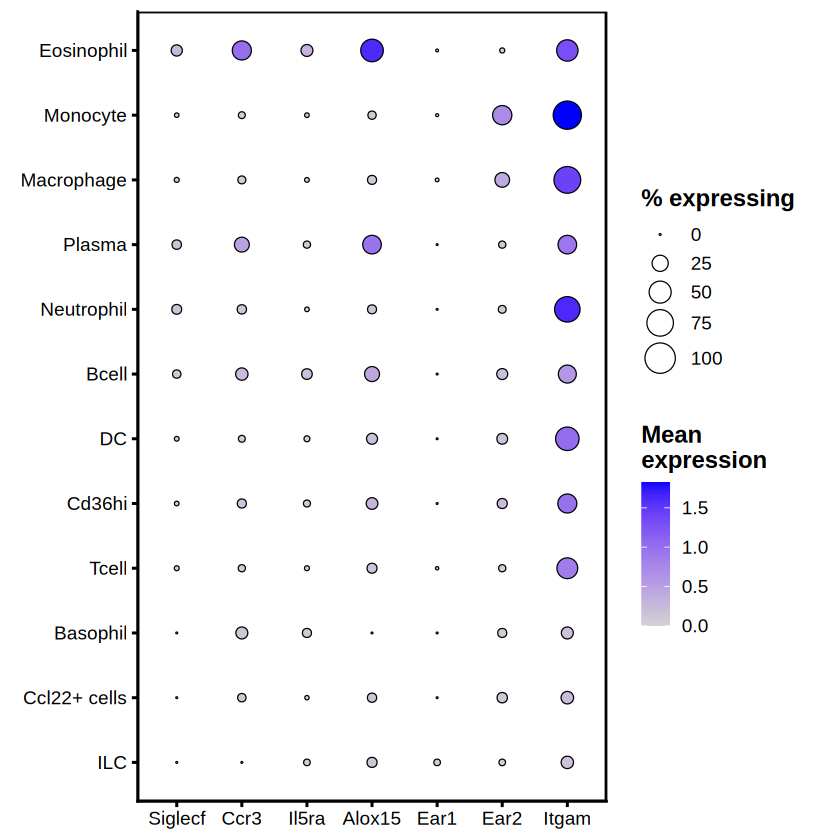

In [63]:
cell_order <- marker_count_summary$CellType

plot_df_bubble <- marker_summary %>%
  mutate(
    CellType = factor(CellType, levels = rev(cell_order)),
    Gene = factor(Gene, levels = markers_use)
  )

p_bubble <- ggplot(
  plot_df_bubble,
  aes(
    x = Gene,
    y = CellType,
    size = pct_expressing,
    fill = mean_expression
  )
) +
  geom_point(
    shape = 21,
    colour = "black",
    stroke = 0.4
  ) +
  scale_size_continuous(
    range = c(0, 8),
    limits = c(0, 100)
  ) +
  labs(
    # title = "Reference expression of key eosinophil-associated markers",
    # subtitle = "Bubble size = % expressing; fill = mean normalized expression",
    x = NULL,
    y = NULL,
    size = "% expressing",
    fill = "Mean\nexpression"
  ) +
    scale_fill_gradient(
      low = "lightgrey",
      high = "blue"
    )+
  theme_cell(base_size = 14)

p_bubble

In [24]:
options(repr.plot.width=10, repr.plot.height=7)

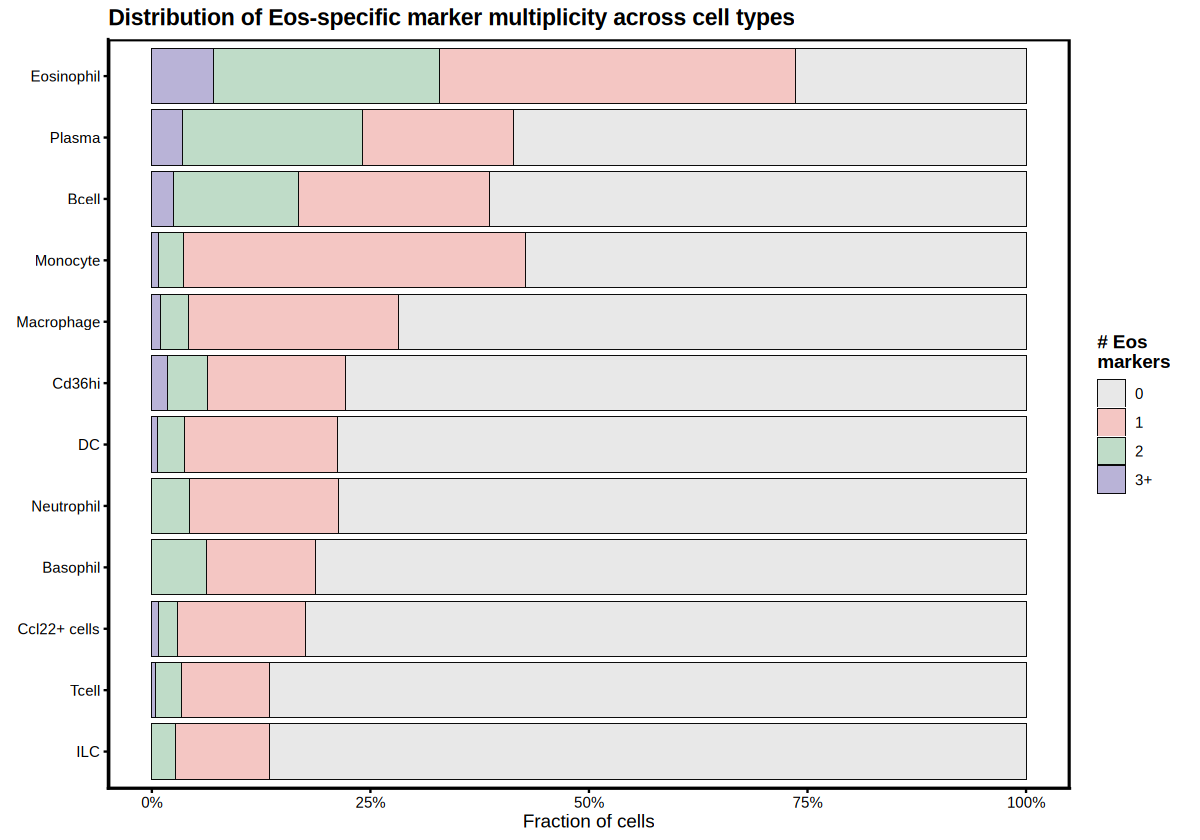

In [25]:
macaron_cols <- c(
  "0"  = "#E8E8E8",
  "1"  = "#F4C6C3",
  "2"  = "#BFDCC8",
  "3+" = "#B9B3D7"
)

plot_df_stack <- ref_df %>%
  mutate(
    CellType = factor(CellType, levels = rev(cell_order)),
    MarkerBin = case_when(
      N_Eos_specific_detected == 0 ~ "0",
      N_Eos_specific_detected == 1 ~ "1",
      N_Eos_specific_detected == 2 ~ "2",
      N_Eos_specific_detected >= 3 ~ "3+"
    )
  ) %>%
  count(CellType, MarkerBin) %>%
  group_by(CellType) %>%
  mutate(
    fraction = n / sum(n)
  ) %>%
  ungroup()

plot_df_stack$MarkerBin <- factor(
  plot_df_stack$MarkerBin,
  levels = c("0", "1", "2", "3+")
)

p_stack <- ggplot(
  plot_df_stack,
  aes(
    x = CellType,
    y = fraction,
    fill = MarkerBin
  )
) +
  geom_col(
    colour = "black",
    linewidth = 0.2
  ) +
  coord_flip() +
  scale_fill_manual(
    values = macaron_cols,
    drop = FALSE
  ) +
  scale_y_continuous(
    labels = percent_format(accuracy = 1)
  ) +
  labs(
    title = "Distribution of Eos-specific marker multiplicity across cell types",
    # subtitle = "Fraction of cells expressing 0, 1, 2, or ≥3 Eos-specific markers",
    x = NULL,
    y = "Fraction of cells",
    fill = "# Eos\nmarkers"
  ) +
  theme_cell(base_size = 11)

p_stack

In [26]:
marker_binary <- sapply(
  markers_use,
  function(g) {
    ref_df[[paste0(g, "_count")]] > 0
  }
)

colnames(marker_binary) <- markers_use

ref_df$Eos_marker_combination <- apply(
  marker_binary,
  1,
  function(x) {

    genes <- markers_use[x]

    if (length(genes) == 0) {
      "None"
    } else {
      paste(genes, collapse = " + ")
    }
  }
)

ref_df$N_Eos_markers_detected <-
  rowSums(marker_binary)

In [27]:
combination_summary <- ref_df %>%
  count(
    CellType,
    Eos_marker_combination,
    name = "n"
  ) %>%
  group_by(CellType) %>%
  mutate(
    fraction = n / sum(n),
    pct = fraction * 100
  ) %>%
  ungroup()

In [28]:
celltypes_compare <- unique(combination_summary$CellType)

combination_compare <- ref_df %>%
  filter(
    CellType %in% celltypes_compare
  ) %>%
  count(
    CellType,
    Eos_marker_combination,
    name = "n"
  ) %>%
  group_by(CellType) %>%
  mutate(
    pct = n / sum(n) * 100
  ) %>%
  ungroup()

In [29]:
combination_keep <- combination_compare %>%
  group_by(Eos_marker_combination) %>%
  summarise(
    max_pct = max(pct),
    .groups = "drop"
  ) %>%
  filter(
    Eos_marker_combination != "None",
    max_pct >= 1
  ) %>%
  pull(Eos_marker_combination)

In [30]:
combination_heatmap_df <- combination_compare %>%
  filter(
    Eos_marker_combination %in%
      combination_keep
  ) %>%
  mutate(
    CellType = factor(
      CellType,
      levels = rev(celltypes_compare)
    )
  )

In [31]:
options(repr.plot.width=12, repr.plot.height=7)

In [32]:
combination_heatmap_df <- combination_compare %>%
  dplyr::filter(
    Eos_marker_combination %in% combination_keep
  ) %>%
  dplyr::mutate(
    Eos_marker_combination =
      as.character(Eos_marker_combination),
    CellType =
      as.character(CellType)
  )

In [33]:
eos_order <- combination_heatmap_df %>%
  dplyr::filter(
    CellType == "Eosinophil"
  ) %>%
  dplyr::arrange(
    dplyr::desc(pct)
  ) %>%
  dplyr::pull(
    Eos_marker_combination
  ) %>%
  unique()

In [34]:
other_order <- combination_heatmap_df %>%
  dplyr::filter(
    !Eos_marker_combination %in% eos_order
  ) %>%
  dplyr::group_by(
    Eos_marker_combination
  ) %>%
  dplyr::summarise(
    max_pct = max(pct, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  dplyr::arrange(
    dplyr::desc(max_pct)
  ) %>%
  dplyr::pull(
    Eos_marker_combination
  )

In [35]:
combination_order <- c(
  eos_order,
  other_order
)

In [36]:
combination_heatmap_df <- combination_heatmap_df %>%
  dplyr::mutate(
    Eos_marker_combination = factor(
      Eos_marker_combination,
      levels = combination_order
    )
  )

In [37]:
table(
  is.na(
    combination_heatmap_df$Eos_marker_combination
  )
)


FALSE 
  163 

In [38]:
celltype_order <- c(
  setdiff(
    celltypes_compare,
    "Eosinophil"
  ),
  "Eosinophil"
)

combination_heatmap_df <- combination_heatmap_df %>%
  dplyr::mutate(
    CellType = factor(
      as.character(CellType),
      levels = celltype_order
    )
  )

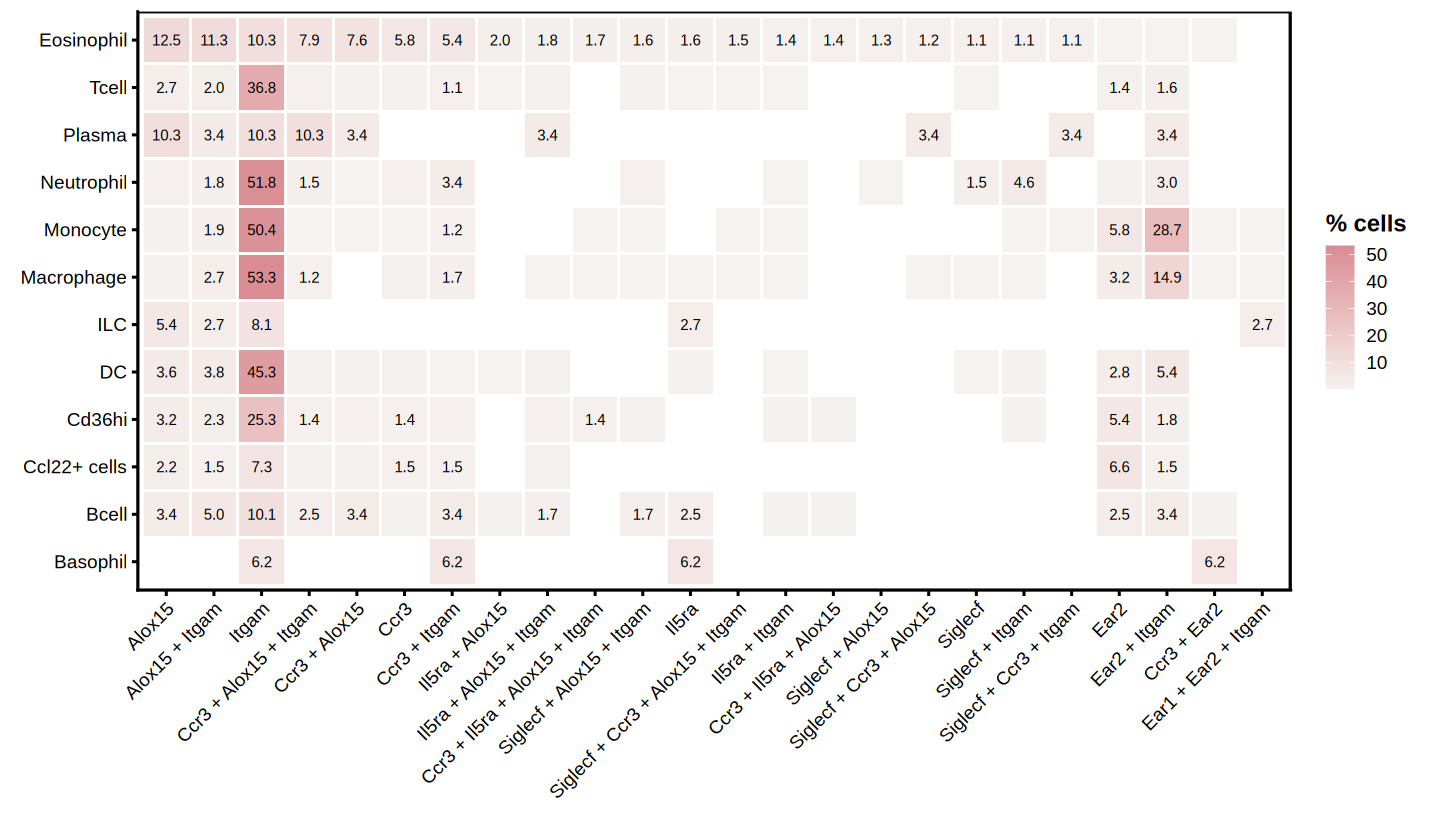

In [39]:
p_combination_heatmap <- ggplot(
  combination_heatmap_df,
  aes(
    x = Eos_marker_combination,
    y = CellType,
    fill = pct
  )
) +
  geom_tile(
    colour = "white",
    linewidth = 0.6
  ) +
  geom_text(
    aes(
      label = ifelse(
        pct >= 1,
        sprintf("%.1f", pct),
        ""
      )
    ),
    size = 3
  ) +
  scale_fill_gradient(
    low = "#F5F2EF",
    high = "#D98C93"
  ) +
  labs(
    x = NULL,
    y = NULL,
    fill = "% cells"
  ) +
  theme_cell(base_size = 14) +
  theme(
    axis.text.x = element_text(
      angle = 45,
      hjust = 1,
      vjust = 1
    )
  )

p_combination_heatmap

In [40]:
marker_count_summary <- ref_df %>%
  group_by(CellType) %>%
  summarise(
    n_cells = n(),

    mean_N_markers =
      mean(N_Eos_markers_detected),

    median_N_markers =
      median(N_Eos_markers_detected),

    pct_ge1 =
      mean(N_Eos_markers_detected >= 1) * 100,

    pct_ge2 =
      mean(N_Eos_markers_detected >= 2) * 100,

    pct_ge3 =
      mean(N_Eos_markers_detected >= 3) * 100,

    pct_ge4 =
      mean(N_Eos_markers_detected >= 4) * 100,

    pct_ge5 =
      mean(N_Eos_markers_detected >= 5) * 100,

    pct_ge6 =
      mean(N_Eos_markers_detected >= 6) * 100,

    pct_ge7 =
      mean(N_Eos_markers_detected >= 7) * 100,

    .groups = "drop"
  ) %>%
  arrange(
    desc(mean_N_markers)
  )

In [41]:
marker_count_summary

CellType,n_cells,mean_N_markers,median_N_markers,pct_ge1,pct_ge2,pct_ge3,pct_ge4,pct_ge5,pct_ge6,pct_ge7
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Eosinophil,3936,1.6082317,2,83.91768,52.311992,20.248984,4.1158537,0.2286585,0,0
Monocyte,1340,1.3298507,1,93.13433,36.044776,3.134328,0.6716418,0.0000000,0,0
Macrophage,918,1.0980392,1,81.48148,23.747277,3.703704,0.7625272,0.1089325,0,0
Plasma,29,1.0344828,1,51.72414,31.034483,20.689655,0.0000000,0.0000000,0,0
Neutrophil,328,0.9420732,1,73.17073,17.378049,3.658537,0.0000000,0.0000000,0,0
Bcell,119,0.9075630,0,48.73950,29.411765,10.084034,1.6806723,0.8403361,0,0
DC,503,0.8330020,1,66.60040,13.916501,2.186879,0.5964215,0.0000000,0,0
Cd36hi,221,0.6651584,0,47.51131,12.217195,5.429864,1.3574661,0.0000000,0,0
Tcell,440,0.6136364,1,50.22727,8.409091,2.272727,0.4545455,0.0000000,0,0


In [42]:
# ============================================================
# Define marker-detection confidence tiers
# ============================================================

tier_markers <- intersect(
  c(
    "Siglecf",
    "Ccr3",
    "Il5ra",
    "Alox15",
    "Ear1",
    "Ear2",
    "Itgam"
  ),
  markers_use
)

required_tier_markers <- c(
  "Siglecf",
  "Ccr3",
  "Il5ra",
  "Alox15",
  "Itgam"
)

missing_required <- setdiff(
  required_tier_markers,
  tier_markers
)

if (length(missing_required) > 0) {
  stop(
    "Required tier markers missing: ",
    paste(missing_required, collapse = ", ")
  )
}


# ============================================================
# Binary detection flags
# ============================================================

ref_df <- ref_df %>%
  dplyr::mutate(

    Siglecf_pos =
      .data[["Siglecf_count"]] > 0,

    Ccr3_pos =
      .data[["Ccr3_count"]] > 0,

    Il5ra_pos =
      .data[["Il5ra_count"]] > 0,

    Alox15_pos =
      .data[["Alox15_count"]] > 0,

    Itgam_pos =
      .data[["Itgam_count"]] > 0,

    # Number of all available Eos-related markers detected
    N_tier_markers_detected =
      rowSums(
        dplyr::across(
          dplyr::all_of(
            paste0(tier_markers, "_count")
          ),
          ~ .x > 0
        )
      )
      )

In [43]:
# ============================================================
# Hierarchical confidence-tier rules
# ============================================================

ref_df <- ref_df %>%
  dplyr::mutate(

    # --------------------------------------------------------
    # Tier 1:
    # strongest core combination
    # --------------------------------------------------------
    Tier1 =
      Siglecf_pos &
      Ccr3_pos,


    # --------------------------------------------------------
    # Tier 2:
    # one core marker
    # +
    # Il5ra or Alox15
    #
    # Tier1 is excluded explicitly.
    # --------------------------------------------------------
    Tier2 =
      !Tier1 &
      (
        (
          Siglecf_pos &
          (Il5ra_pos | Alox15_pos)
        ) |
        (
          Ccr3_pos &
          (Il5ra_pos | Alox15_pos)
        )
      ),


    # --------------------------------------------------------
    # Tier 3:
    # one core marker
    # +
    # Itgam
    #
    # Only reached if Tier1 / Tier2 were not satisfied.
    # --------------------------------------------------------
    Tier3 =
      !Tier1 &
      !Tier2 &
      (
        (
          Siglecf_pos &
          Itgam_pos
        ) |
        (
          Ccr3_pos &
          Itgam_pos
        )
      ),


    # --------------------------------------------------------
    # Tier 4:
    # any remaining >=2-marker combination
    #
    # e.g.
    # Siglecf + Ear1
    # Ccr3 + Ear2
    # Il5ra + Alox15
    # Alox15 + Itgam
    # etc.
    # --------------------------------------------------------
    Tier4 =
      !Tier1 &
      !Tier2 &
      !Tier3 &
      N_tier_markers_detected >= 2,


    # --------------------------------------------------------
    # Final mutually exclusive category
    # --------------------------------------------------------
    Eos_confidence_tier =
      dplyr::case_when(

        Tier1 ~
          "Conf Tier1",

        Tier2 ~
          "Conf Tier2",

        Tier3 ~
          "Conf Tier3",

        Tier4 ~
          "Conf Tier4",

        TRUE ~
          "Rest"
      )
  )

In [44]:
table(
  ref_df$Eos_confidence_tier,
  useNA = "ifany"
)


Conf Tier1 Conf Tier2 Conf Tier3 Conf Tier4       Rest 
       201       1026        366       1416       5015 

In [45]:
# ============================================================
# Macaron tier colors
# ============================================================

tier_cols <- c(
  "Conf Tier1" = "#E89A8F",
  "Conf Tier2" = "#F4C6C3",
  "Conf Tier3" = "#F4D6A0",
  "Conf Tier4" = "#BFDCC8",
  "Rest"       = "#E8E8E8"
)

In [46]:
tier_order <- c(
  "Conf Tier1",
  "Conf Tier2",
  "Conf Tier3",
  "Conf Tier4",
  "Rest"
)

ref_df <- ref_df %>%
  dplyr::mutate(
    Eos_confidence_tier = factor(
      Eos_confidence_tier,
      levels = tier_order
    )
  )

In [47]:
# ============================================================
# Percentage within each reference cell type
# ============================================================

plot_df_tier <- ref_df %>%
  dplyr::mutate(
    CellType = factor(
      CellType,
      levels = rev(cell_order)
    )
  ) %>%
  dplyr::count(
    CellType,
    Eos_confidence_tier,
    name = "n"
  ) %>%
  dplyr::group_by(
    CellType
  ) %>%
  dplyr::mutate(
    n_total = sum(n),
    fraction = n / n_total,
    percent = 100 * fraction
  ) %>%
  dplyr::ungroup()

In [59]:
# Total number of cells per cell type
celltype_n <- ref_df %>%
  dplyr::count(
    CellType,
    name = "n_total"
  )

celltype_n

CellType,n_total
<chr>,<int>
Basophil,16
Bcell,119
Ccl22+ cells,137
Cd36hi,221
DC,503
Eosinophil,3936
ILC,37
Macrophage,918
Monocyte,1340


In [60]:
celltype_labels <- celltype_n %>%
  dplyr::mutate(
    label = paste0(
      CellType,
      " (n=",
      scales::comma(n_total),
      ")"
    )
  )

celltype_label_vec <- setNames(
  celltype_labels$label,
  celltype_labels$CellType
)

In [65]:
options(repr.plot.width=12, repr.plot.height=7)

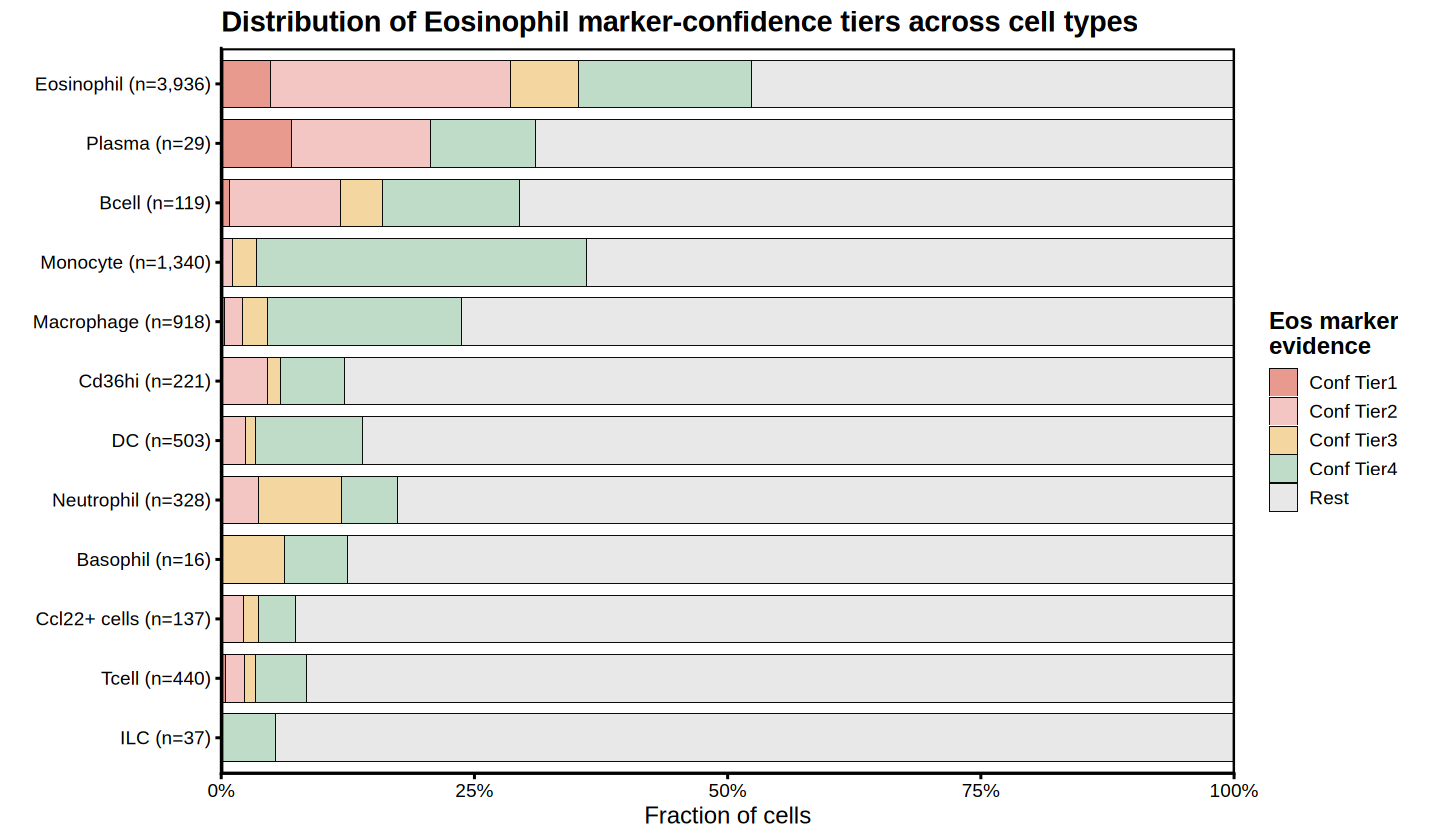

In [66]:
p_tier_stack <- ggplot(
  plot_df_tier,
  aes(
    x = CellType,
    y = fraction,
    fill = Eos_confidence_tier
  )
) +

  geom_col(
    position = position_stack(reverse = TRUE),
    colour = "black",
    linewidth = 0.2,
    width = 0.8
  ) +

  coord_flip() +

  scale_fill_manual(
    values = tier_cols,
    breaks = tier_order,
    drop = FALSE
  ) +

  scale_x_discrete(
    labels = celltype_label_vec
  ) +

  scale_y_continuous(
    labels = scales::percent_format(
      accuracy = 1
    ),
    expand = c(0, 0)
  ) +

  labs(
    title = "Distribution of Eosinophil marker-confidence tiers across cell types",
    x = NULL,
    y = "Fraction of cells",
    fill = "Eos marker\nevidence"
  ) +

  theme_cell(
    base_size = 14
  )

p_tier_stack